## Part 1

In [258]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/indian-liver-patient-records")

# First let's explore the data
df = pd.read_csv(path + "/indian_liver_patient.csv")

# Take a look at some rows and overall numbers across dataset
print("First 5 rows:")
display(df.head())
print("Last 5 rows:")
display(df.tail())
print("Shape:", df.shape,"\n")
print("Info:")
df.info()
print("\nSummary Statistics:")
display(df.describe())

# Missing values or duplicates
print("Null values: \n", df.isnull().sum()) # 4 nulls in Albumin_and_Globulin_Ratio column
print("\nDuplicate rows:", df.duplicated().sum()) # 13 duplicates

First 5 rows:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


Last 5 rows:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


Shape: (583, 11) 

Info:
<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB

Summary Statistics:


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


Null values: 
 Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

Duplicate rows: 13


In [ ]:
import matplotlib.pyplot as plt

# Create some plots to see how some columns correlate with disease
# Data shows that fewer disease patients are young
age_plot = df.iloc[df['Dataset']==1].groupby('Age')[['Dataset']].count().reset_index() # Queried ChatGPT to find out I needed to reset_index
age_plot.plot(x='Age',y='Dataset', kind='scatter', title='Number of Liver Disease Patients by Age', ylabel='Number of Patients')

# # Data shows that most disease patients are males, could be biased dataset though
gender_plot = df.iloc[df['Dataset']==1].groupby('Gender')[['Dataset']].count().reset_index()
gender_plot.plot(x='Gender', y='Dataset', kind='bar', title='Number of Liver Disease Patients by Gender', ylabel='Number of Patients', legend=False)

# Data shows that patients with higher bilirubin levels are more likely to have liver disease, this makes sense as the liver processes bilirubin
plt.figure()
bilirubin_plot1 = df.iloc[df['Dataset']==1].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
bilirubin_plot2 = df.iloc[df['Dataset']==2].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
plt.scatter(bilirubin_plot1['Total_Bilirubin'], bilirubin_plot1['Dataset'], label='Liver Disease')
plt.scatter(bilirubin_plot2['Total_Bilirubin'], bilirubin_plot2['Dataset'], label='No Liver Disease')
plt.xlabel('Total Bilirubin')
plt.ylabel('Number of Patients')
plt.title('Number of Liver Patients by Bilirubin')
plt.legend()
plt.show()

# Data shows that patients with higher Alkaline_Phosphotase levels are more likely to have liver disease
plt.figure()
df_disease = df.iloc[df['Dataset']==1]
df_no_disease = df.iloc[df['Dataset']==2]
plt.scatter(df_disease['Alkaline_Phosphotase'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Alkaline_Phosphotase'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Alkaline_Phosphotase')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Alkaline_Phosphotase')
plt.legend()
plt.show()

# Data shows that total protein does not indicate much
plt.figure()
plt.scatter(df_disease['Total_Protiens'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Total_Protiens'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Total_Protein')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Total_Protein')
plt.legend()
plt.show()

# Data shows that Albumin does not indicate much
plt.figure(figsize=(10,5))
plt.scatter(df_disease['Albumin'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Albumin'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Albumin')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Albumin')
plt.legend()
plt.show()

In [ ]:
import numpy as np

# Detect anomalies with IQR, Total bilirubin
Q1 = df['Total_Bilirubin'].quantile(0.25)
Q3 = df['Total_Bilirubin'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
bilirubin_outliers = df[(df['Total_Bilirubin'] < lower) | (df['Total_Bilirubin'] > upper)]
print("Bilirubin Outliers:\n")
display(bilirubin_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Total_Bilirubin'], orientation='horizontal')
ax.set_title('Total_Bilirubin')
plt.show()

# Alkaline Phosphotase
Q1 = df['Alkaline_Phosphotase'].quantile(0.25)
Q3 = df['Alkaline_Phosphotase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
alkaline_phosphotase_outliers = df[(df['Alkaline_Phosphotase'] < lower) | (df['Alkaline_Phosphotase'] > upper)]
print("Alkaline_Phosphotase Outliers:\n")
display(alkaline_phosphotase_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Alkaline_Phosphotase'], orientation='horizontal')
ax.set_title('Alkaline_Phosphotase')
plt.show()

# Alamine_Aminotransferase
Q1 = df['Alamine_Aminotransferase'].quantile(0.25)
Q3 = df['Alamine_Aminotransferase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
alamine_aminotransferase_outliers = df[(df['Alamine_Aminotransferase'] < lower) | (df['Alamine_Aminotransferase'] > upper)]
print("Alamine_Aminotransferase Outliers:\n")
display(alamine_aminotransferase_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Alamine_Aminotransferase'], orientation='horizontal')
ax.set_title('Alamine_Aminotransferase')
plt.show()

# Total_Protiens
Q1 = df['Total_Protiens'].quantile(0.25)
Q3 = df['Total_Protiens'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
total_protiens_outliers = df[(df['Total_Protiens'] < lower) | (df['Total_Protiens'] > upper)]
print("Total_Protiens Outliers:\n")
display(total_protiens_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Total_Protiens'], orientation='horizontal')
ax.set_title('Total_Protiens')
plt.show()

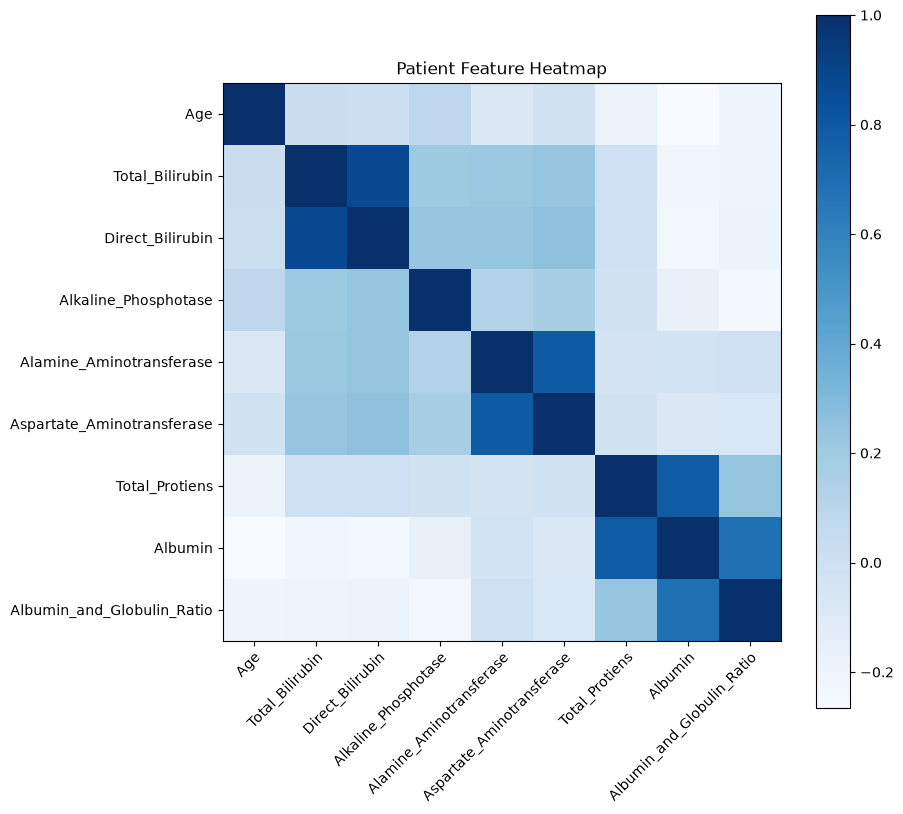

In [259]:
# Create a heatmap to check correlation between features, I used YouTube and Google's AI overview for syntax/formatting help
numerical_df = df.drop(['Gender', 'Dataset'], axis=1)
corr_df = numerical_df.corr()

fig = plt.figure(figsize=(9,9))
plt.imshow(corr_df, cmap='Blues')
plt.colorbar()
plt.xticks(range(9),corr_df.index, rotation=45, ha='right',rotation_mode='anchor')
plt.yticks(range(9),corr_df.index, ha='right',rotation_mode='anchor')
plt.title("Patient Feature Heatmap")
plt.show()

In [279]:
# Clean up the dataset

# Reduce multicollinearity as per the heat map
clean_df = df.drop(['Direct_Bilirubin','Aspartate_Aminotransferase','Albumin'],axis=1)
# Drop duplicate rows
clean_df.drop_duplicates()
# Winsorize extreme values
from scipy.stats.mstats import winsorize
clean_df['Total_Bilirubin'] = winsorize(clean_df['Total_Bilirubin'],limits=[0.25, 0.25]) # Used ChatGPT to find out I can reassign easily
clean_df['Alkaline_Phosphotase'] = winsorize(clean_df['Alkaline_Phosphotase'],limits=[0.25, 0.25])
clean_df['Alamine_Aminotransferase'] = winsorize(clean_df['Alamine_Aminotransferase'],limits=[0.25, 0.25])
clean_df['Total_Protiens'] = winsorize(clean_df['Total_Protiens'],limits=[0.25, 0.25])